In [44]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library yang diperlukan untuk proses pengolahan citra, ekstraksi fitur, klasifikasi, dan evaluasi model. Library os digunakan untuk mengakses serta mengelola file dan folder dataset, sedangkan OpenCV (cv2) digunakan untuk membaca, mengubah, dan memproses citra digital. NumPy (np) berfungsi untuk mengolah data dalam bentuk array dan melakukan perhitungan numerik secara efisien, sementara Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil pengolahan. Pandas (pd) digunakan untuk menyimpan dan mengelola data hasil ekstraksi fitur dalam bentuk tabel. Library scikit-learn menyediakan berbagai fungsi untuk klasifikasi, evaluasi model, dan pembagian data, sedangkan skimage.feature digunakan untuk menghitung matriks GLCM dan fitur teksturnya. scipy.stats digunakan untuk menghitung nilai entropy, dan seaborn digunakan untuk visualisasi heatmap korelasi antar fitur.

In [45]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("Assets"):
    sub_folder_files = os.listdir(os.path.join("Assets", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 298
Kelas: ['Coal', 'Limestone', 'Sandstone']


Kode ini digunakan untuk membaca seluruh citra yang terdapat pada folder dataset dan mempersiapkannya untuk proses pengolahan selanjutnya. Program terlebih dahulu membuat tiga list, yaitu data untuk menyimpan citra mentah, labels untuk menyimpan kelas citra berdasarkan nama subfolder, dan file_name untuk menyimpan nama file gambar. Selanjutnya program melakukan perulangan pada setiap subfolder di dalam folder Assets. Setiap subfolder dianggap sebagai sebuah kelas data. Setiap gambar dibaca menggunakan cv.imread(), kemudian dilakukan pengecekan untuk memastikan gambar berhasil dimuat. Pada tahap ini citra belum diproses, melainkan disimpan dalam bentuk aslinya agar preprocessing dapat dilakukan secara terpisah dan terstruktur.

# Data Preparation

### Define Preprocessing Function

In [46]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median_filter(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_result = cv.medianBlur(img, kernel_size)
    return median_result


def histogram_equalization_grayscale(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    equalized_result = cv.equalizeHist(img)

    return equalized_result

In [47]:
def prepro(image):
    # Resize + Grayscale
    img = resize_grayscale(image)
    # median_filter
    img = median_filter(img)
    # histogram_equalization_grayscale
    img = histogram_equalization_grayscale(img)
    return img

Kode ini berisi beberapa fungsi yang digunakan pada tahap preprocessing citra. Fungsi resize_grayscale() digunakan untuk mengubah ukuran gambar menjadi 128×128 piksel agar seluruh citra memiliki dimensi yang seragam, kemudian mengonversi citra ke grayscale (jika citra input masih memiliki 3 channel warna) sehingga setiap piksel hanya memiliki satu nilai intensitas dengan tipe data uint8.

Fungsi median_filter() digunakan untuk mereduksi noise pada citra menggunakan filter Median dengan ukuran kernel 5×5. Berbeda dengan filter rata-rata, Median Filter bekerja dengan cara mengambil nilai tengah (median) dari intensitas piksel di dalam area kernel. Metode ini sangat efektif dan andal untuk menghilangkan noise acak jenis salt-and-pepper yang sering ditemukan pada foto batuan, tanpa mengaburkan tepi-tepi penting pada tekstur citra.

Fungsi histogram_equalization_grayscale() digunakan untuk meningkatkan kontras citra yang sudah berformat grayscale. Fungsi ini bekerja dengan meratakan distribusi akumulatif dari histogram intensitas piksel (menggunakan fungsi cv.equalizeHist()). Proses ini membuat detail-detail tekstur batuan yang awalnya samar atau terlalu gelap/terang menjadi lebih tegas, seimbang, dan lebih mudah dikenali oleh algoritma ekstraksi fitur.

Fungsi prepro() merupakan fungsi utama yang mengintegrasikan seluruh tahapan preprocessing secara berurutan, dimulai dari penyeragaman ukuran dan konversi warna (Resize & Grayscale), pembersihan bintik pengganggu (Median Filter), hingga peningkatan kualitas detail kontras (Histogram Equalization).

## Percobaan 2 (Resize + Grayscale + Median Filter + Histogram Equalization)


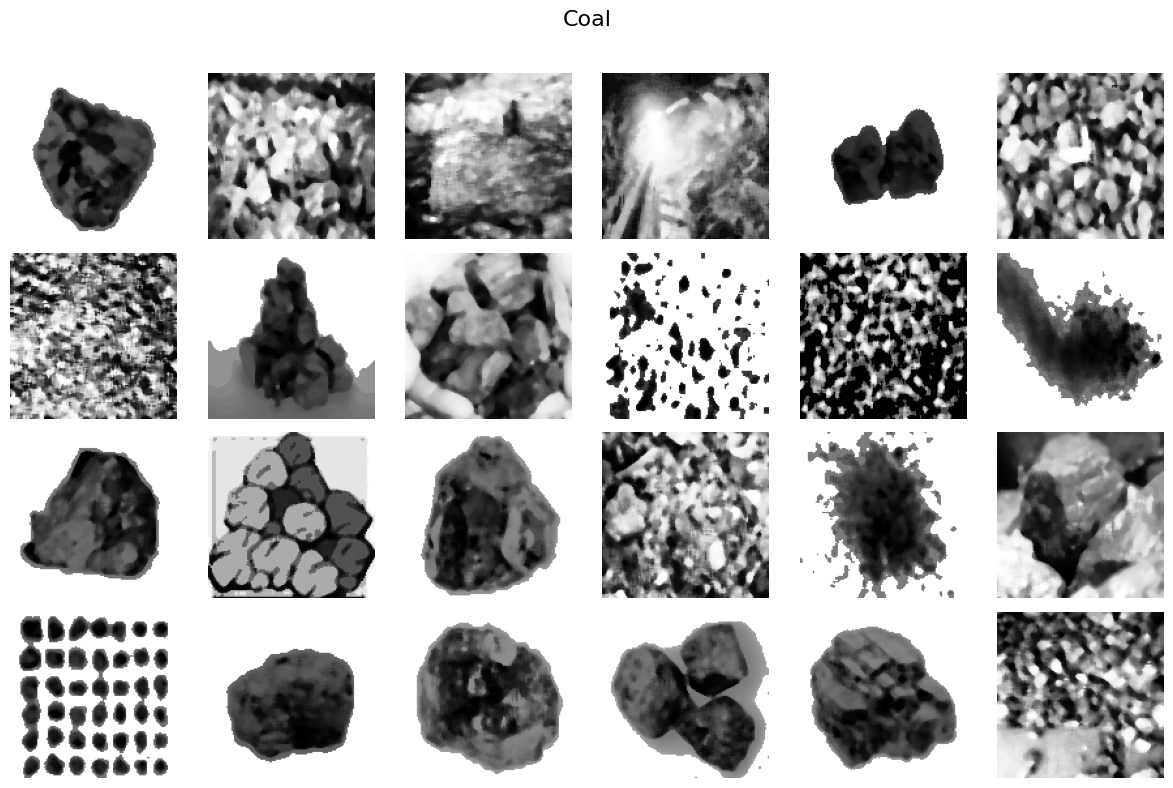

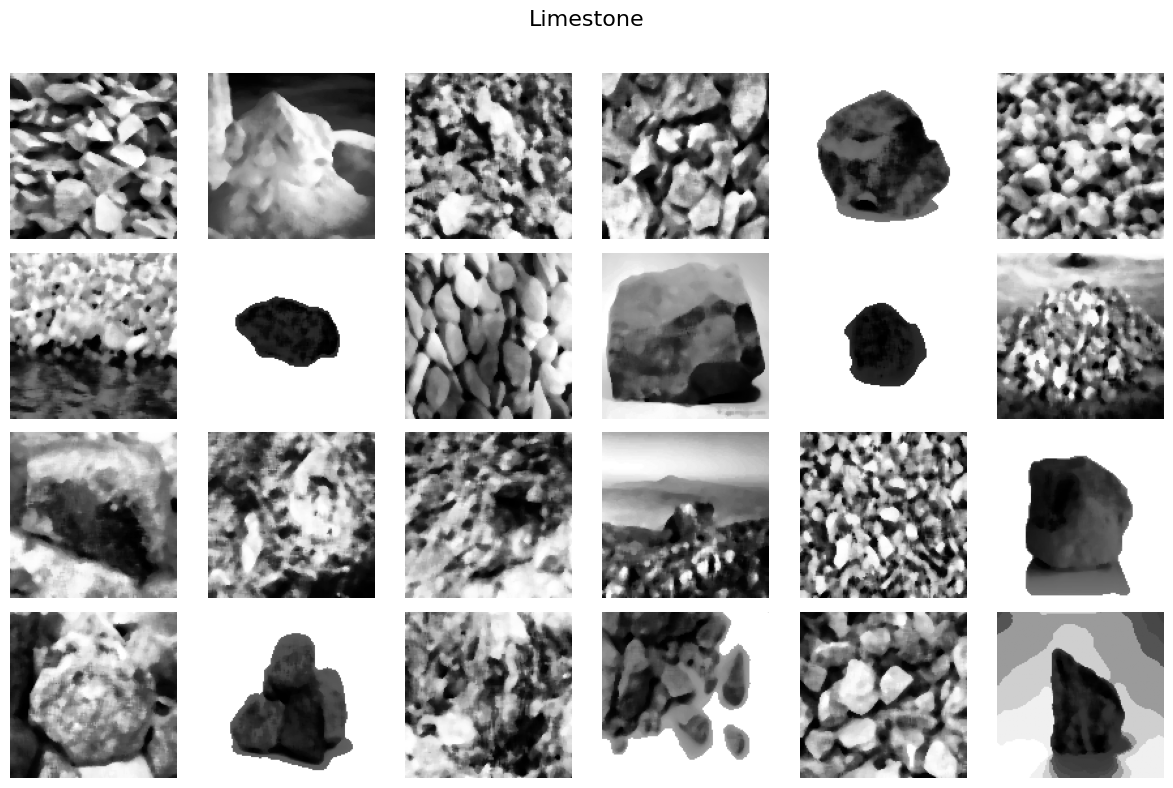

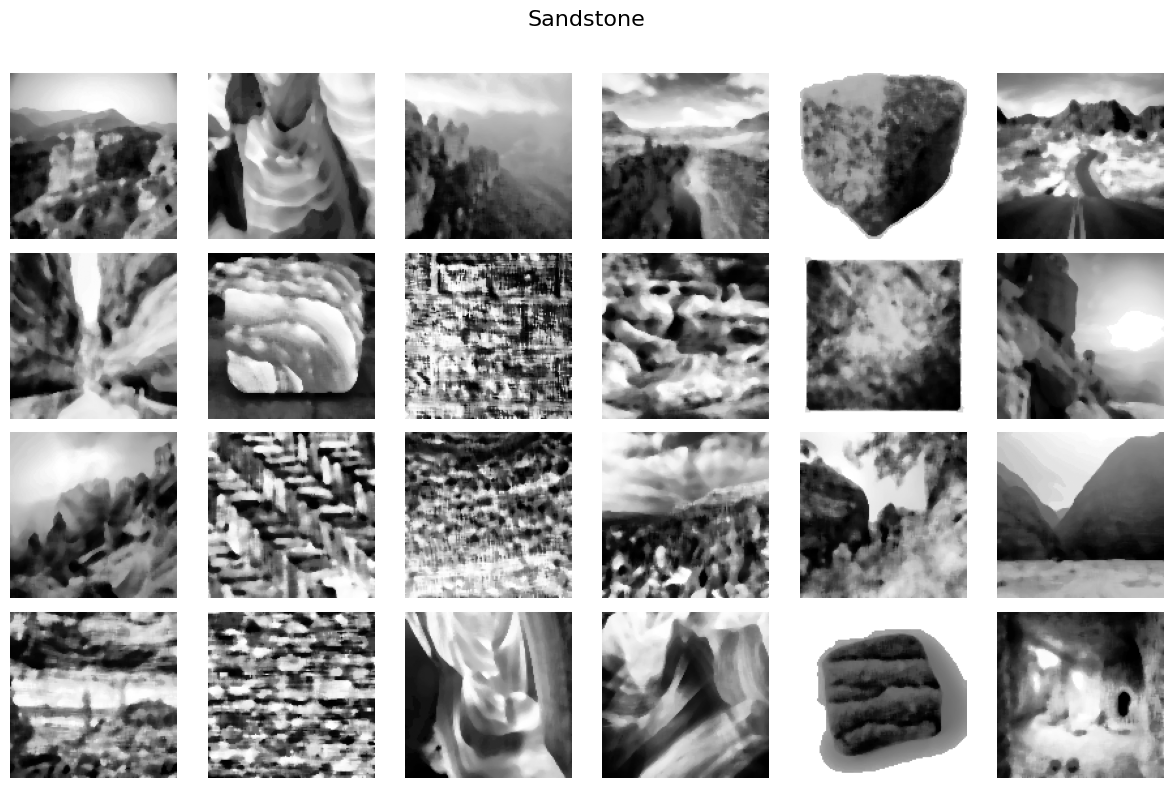

In [48]:
def percobaan2(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [49]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode ini digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM) dari sebuah citra. Fungsi glcm() menerima dua parameter, yaitu image yang merupakan citra masukan dan derajat yang menunjukkan arah hubungan antar piksel yang akan dianalisis. Program terlebih dahulu mengubah nilai sudut yang diberikan, yaitu 0°, 45°, 90°, atau 135°, ke dalam satuan radian karena fungsi graycomatrix() menggunakan radian sebagai parameter sudut. Jika nilai sudut yang dimasukkan tidak sesuai dengan pilihan yang tersedia, program akan menampilkan pesan kesalahan.

Setelah sudut ditentukan, fungsi graycomatrix() dipanggil dengan parameter distance bernilai 1, artinya hubungan antar piksel dihitung berdasarkan piksel yang langsung bersebelahan. Parameter symmetric=True digunakan agar matriks bersifat simetris, dan normed=True digunakan agar nilai matriks dinormalisasi sehingga jumlah seluruh elemennya bernilai 1.

In [50]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode ini digunakan untuk menghitung berbagai fitur tekstur dari matriks Gray Level Co-occurrence Matrix (GLCM). Setiap fungsi menerima parameter berupa matriks GLCM yang telah dibentuk sebelumnya, kemudian menghitung karakteristik tekstur tertentu menggunakan fungsi graycoprops() dari pustaka scikit-image. Fitur correlation digunakan untuk mengukur hubungan atau ketergantungan antar nilai piksel yang berdekatan. Fitur dissimilarity mengukur tingkat perbedaan nilai keabuan antar pasangan piksel, sedangkan homogeneity mengukur tingkat keseragaman tekstur pada citra. Fitur contrast digunakan untuk mengukur perbedaan intensitas antara piksel dan tetangganya, ASM (Angular Second Moment) mengukur keseragaman distribusi nilai intensitas, dan energy merupakan akar kuadrat dari ASM. Fitur entropy dihitung secara manual menggunakan fungsi dari scipy.stats untuk mengukur tingkat ketidakaturan atau kompleksitas tekstur citra.

In [51]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 298 citra.


Kode ini digunakan untuk melakukan ekstraksi fitur tekstur GLCM pada seluruh citra hasil preprocessing. Pertama, program membuat empat list kosong untuk menyimpan matriks GLCM berdasarkan arah sudut 0°, 45°, 90°, dan 135°. Setiap citra pada dataPreprocessed kemudian diproses menggunakan fungsi glcm() pada keempat sudut tersebut, lalu hasil matriksnya disimpan ke dalam list sesuai arah sudutnya.

Setelah matriks GLCM terbentuk, program membuat beberapa list kosong untuk menyimpan nilai fitur tekstur dari masing-masing sudut. Fitur yang dihitung meliputi correlation, contrast, dissimilarity, homogeneity, entropy, ASM, dan energy. Setiap fitur dihitung untuk keempat arah sudut sehingga menghasilkan 28 fitur secara keseluruhan per citra.

## Ekstraksi ke CSV
Kode ini digunakan untuk menggabungkan seluruh hasil ekstraksi fitur GLCM ke dalam sebuah tabel yang terstruktur. Program membuat sebuah dictionary bernama dataTable yang berisi nama file, label kelas, serta seluruh fitur tekstur yang telah dihitung sebelumnya, yaitu contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation pada sudut 0°, 45°, 90°, dan 135°. Setiap kolom pada dictionary merepresentasikan satu jenis fitur, sedangkan setiap baris merepresentasikan satu citra.
Selanjutnya dictionary tersebut dikonversi menjadi DataFrame menggunakan Pandas dan disimpan ke dalam file CSV bernama hasil_ekstraksi_Percobaan3.csv agar dapat digunakan kembali tanpa perlu menghitung ulang fitur dari awal.

In [52]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi_Percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi_Percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Limestone_1.jpg,Limestone,532.897392,1019.058714,927.873093,1439.583173,0.281550,0.193705,0.239688,0.172145,...,0.000775,0.000529,0.031344,0.024764,0.027840,0.023011,0.952048,0.908257,0.916460,0.870394
1,Limestone_2.jpg,Limestone,183.574126,224.267097,184.031988,374.546655,0.410130,0.290686,0.376008,0.291270,...,0.001059,0.000835,0.038800,0.028659,0.032539,0.028889,0.983018,0.979184,0.982914,0.965239
2,Limestone_3.jpg,Limestone,833.662032,1194.100688,787.996371,1534.537727,0.222636,0.173393,0.236477,0.152130,...,0.000539,0.000315,0.022382,0.018919,0.023214,0.017743,0.923364,0.890076,0.927431,0.858745
3,Limestone_4.jpg,Limestone,654.665908,1168.251845,510.099594,808.646041,0.267296,0.185911,0.279659,0.206862,...,0.001881,0.001320,0.041671,0.034199,0.043372,0.036326,0.940645,0.894168,0.953881,0.926749
4,Limestone_5.jpg,Limestone,341.324557,470.252589,329.390502,563.837312,0.693480,0.639317,0.673573,0.639916,...,0.285195,0.278139,0.534440,0.528252,0.534036,0.527389,0.983069,0.976708,0.983661,0.972073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,Coal_95.jpg,Coal,408.025283,627.324819,371.529158,738.390911,0.275092,0.203313,0.267188,0.192502,...,0.000802,0.000549,0.029209,0.024649,0.028321,0.023437,0.962408,0.941945,0.965694,0.931671
294,Coal_96.jpg,Coal,653.716720,1101.077872,605.343442,1048.094612,0.275373,0.218472,0.300294,0.214621,...,0.003302,0.002381,0.055245,0.048878,0.057462,0.048798,0.940695,0.900027,0.945025,0.904832
295,Coal_97.jpg,Coal,430.357283,613.112158,411.036294,721.660115,0.770534,0.737487,0.771630,0.735223,...,0.439392,0.430549,0.662741,0.657652,0.662867,0.656163,0.978824,0.969953,0.979775,0.964633
296,Coal_98.jpg,Coal,334.135950,519.165726,325.374139,507.473247,0.673468,0.623478,0.684188,0.641002,...,0.264205,0.257047,0.514374,0.506809,0.514009,0.506998,0.983126,0.973808,0.983568,0.974397


## Feature Selection
Seleksi fitur dilakukan menggunakan metode korelasi antar fitur dengan threshold 0.95. Fitur yang memiliki nilai korelasi absolut lebih dari atau sama dengan threshold akan dihapus karena dianggap membawa informasi yang sama dengan fitur lain sehingga bersifat redundan.

Proses seleksi dimulai dengan menghitung matriks korelasi dari seluruh fitur hasil ekstraksi. Kemudian dibuat array boolean yang menandai fitur mana yang akan dipertahankan. Jika dua fitur memiliki korelasi absolut ≥ 0.95, maka fitur kedua (j) akan ditandai untuk dihapus. Fitur-fitur yang lolos seleksi kemudian digunakan sebagai input model klasifikasi.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 7
Fitur terpilih        : ['Contrast0', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'ASM0', 'Correlation0', 'Correlation90']


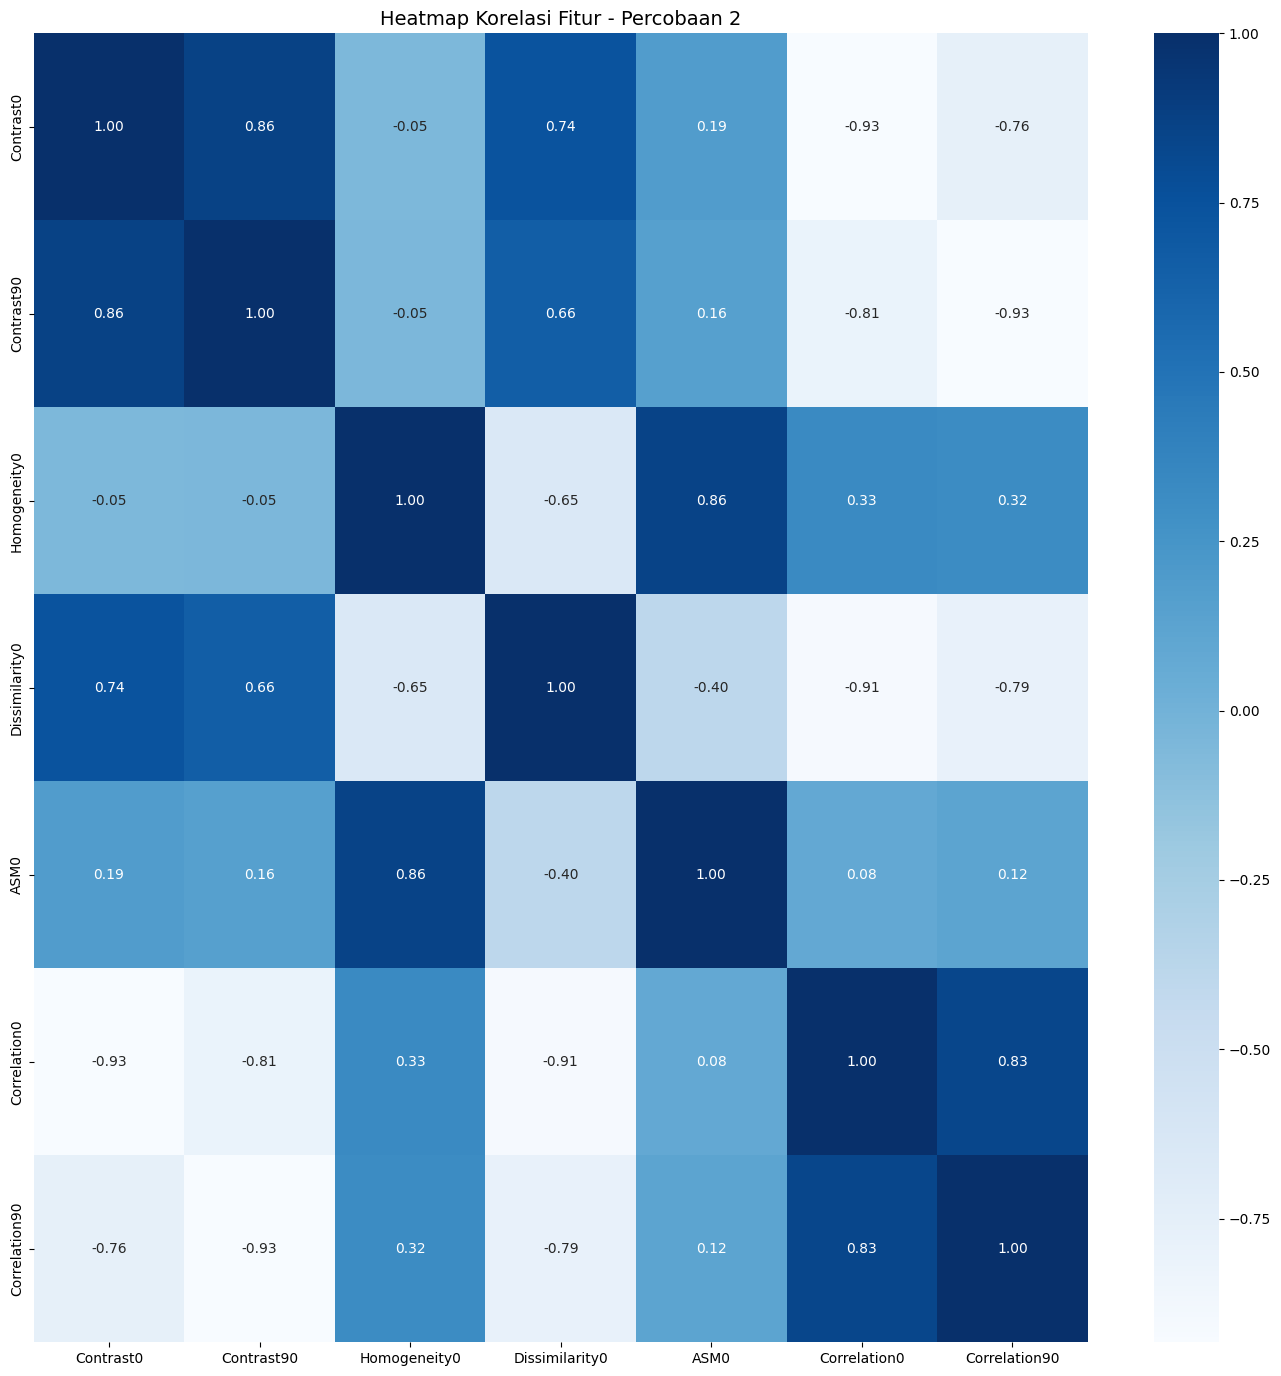

In [53]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 2', fontsize=14)
plt.show()

In [54]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)


(238, 7)
(60, 7)


## Splitting Data
Data dibagi menjadi dua bagian yaitu data training dan data testing menggunakan perbandingan 80:20, artinya 80% data digunakan untuk melatih model dan 20% sisanya digunakan untuk menguji performa model. Pembagian ini dipilih karena jumlah data yang tersedia tidak terlalu banyak, sehingga porsi training yang lebih besar dapat membantu model belajar lebih optimal. Pembagian dilakukan menggunakan fungsi train_test_split() dengan random_state=42 agar hasil pembagian konsisten dan dapat direproduksi.

In [55]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Normalisasi Fitur
Normalisasi dilakukan menggunakan metode Z-score (Standardization), yaitu dengan mengurangi nilai rata-rata lalu dibagi dengan standar deviasi. Proses normalisasi menggunakan parameter mean dan standar deviasi dari data training, dan parameter yang sama diterapkan juga ke data testing. Hal ini dilakukan agar tidak terjadi data leakage, yaitu kondisi di mana informasi dari data testing ikut mempengaruhi proses training. Setelah normalisasi, setiap fitur akan memiliki distribusi dengan rata-rata mendekati 0 dan standar deviasi mendekati 1, sehingga seluruh fitur berada dalam skala yang seragam dan model tidak terpengaruh oleh perbedaan skala antar fitur.

# MODELING

In [56]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Define Model
Kode ini digunakan untuk menyiapkan proses evaluasi dan klasifikasi data. Fungsi generateClassificationReport() dibuat untuk menampilkan hasil evaluasi model klasifikasi. Fungsi ini menerima data label sebenarnya (y_true) dan hasil prediksi model (y_pred), kemudian menampilkan classification report yang berisi nilai precision, recall, f1-score, dan support untuk setiap kelas. Selain itu, fungsi juga menampilkan confusion matrix untuk melihat jumlah prediksi yang benar maupun salah pada masing-masing kelas, serta nilai accuracy untuk mengetahui tingkat ketepatan model secara keseluruhan.

Tiga model klasifikasi yang digunakan adalah Random Forest dengan 5 pohon keputusan, Support Vector Machine (SVM) dengan kernel RBF, dan K-Nearest Neighbors (KNN) dengan nilai k=5.

## Hasil Modeling Random Forest
* ### Training Set
Isi analisis hasil training Random Forest pada Percobaan 1 di sini setelah menjalankan notebook.
* ### Testing Set
Isi analisis hasil testing Random Forest pada Percobaan 1 di sini setelah menjalankan notebook.

In [57]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

        Coal       0.96      0.95      0.96        85
   Limestone       0.90      0.92      0.91        75
   Sandstone       0.95      0.94      0.94        78

    accuracy                           0.94       238
   macro avg       0.94      0.94      0.94       238
weighted avg       0.94      0.94      0.94       238

[[81  3  1]
 [ 3 69  3]
 [ 0  5 73]]
Accuracy: 0.9369747899159664

------Testing Set------
              precision    recall  f1-score   support

        Coal       0.41      0.86      0.56        14
   Limestone       0.62      0.45      0.53        22
   Sandstone       0.53      0.33      0.41        24

    accuracy                           0.50        60
   macro avg       0.52      0.55      0.50        60
weighted avg       0.54      0.50      0.49        60

[[12  0  2]
 [ 7 10  5]
 [10  6  8]]
Accuracy: 0.5


## Hasil Modeling SVM
* ### Training Set
Isi analisis hasil training SVM pada Percobaan 1 di sini setelah menjalankan notebook.
* ### Testing Set
Isi analisis hasil testing SVM pada Percobaan 1 di sini setelah menjalankan notebook.

In [58]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

        Coal       0.66      0.65      0.65        85
   Limestone       0.54      0.41      0.47        75
   Sandstone       0.61      0.77      0.68        78

    accuracy                           0.61       238
   macro avg       0.61      0.61      0.60       238
weighted avg       0.61      0.61      0.61       238

[[55 14 16]
 [22 31 22]
 [ 6 12 60]]
Accuracy: 0.6134453781512605

------Testing Set------
              precision    recall  f1-score   support

        Coal       0.43      0.64      0.51        14
   Limestone       0.62      0.36      0.46        22
   Sandstone       0.65      0.71      0.68        24

    accuracy                           0.57        60
   macro avg       0.57      0.57      0.55        60
weighted avg       0.59      0.57      0.56        60

[[ 9  3  2]
 [ 7  8  7]
 [ 5  2 17]]
Accuracy: 0.5666666666666667


## Hasil Modeling KNN
* ### Training Set
Isi analisis hasil training KNN pada Percobaan 1 di sini setelah menjalankan notebook.
* ### Testing Set
Isi analisis hasil testing KNN pada Percobaan 1 di sini setelah menjalankan notebook.

In [59]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

        Coal       0.64      0.71      0.67        85
   Limestone       0.49      0.52      0.51        75
   Sandstone       0.74      0.62      0.67        78

    accuracy                           0.62       238
   macro avg       0.62      0.61      0.62       238
weighted avg       0.63      0.62      0.62       238

[[60 19  6]
 [25 39 11]
 [ 9 21 48]]
Accuracy: 0.6176470588235294

------Testing Set------
              precision    recall  f1-score   support

        Coal       0.42      0.79      0.55        14
   Limestone       0.67      0.36      0.47        22
   Sandstone       0.59      0.54      0.57        24

    accuracy                           0.53        60
   macro avg       0.56      0.56      0.53        60
weighted avg       0.58      0.53      0.53        60

[[11  1  2]
 [ 7  8  7]
 [ 8  3 13]]
Accuracy: 0.5333333333333333


## Evaluasi Confusion Matrix
Confusion matrix digunakan untuk melihat secara detail bagaimana model melakukan prediksi pada setiap kelas. Sumbu vertikal menunjukkan label sebenarnya (true label) dan sumbu horizontal menunjukkan label yang diprediksi (predicted label). Angka 0 merepresentasikan Coal, 1 merepresentasikan Limestone, dan 2 merepresentasikan Sandstone.

Isi analisis confusion matrix dari ketiga model pada Percobaan 1 di sini setelah menjalankan notebook.

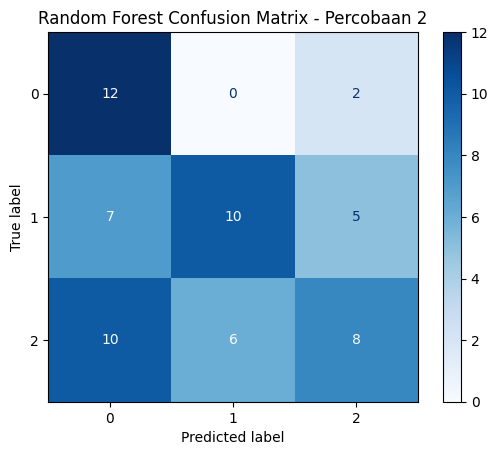

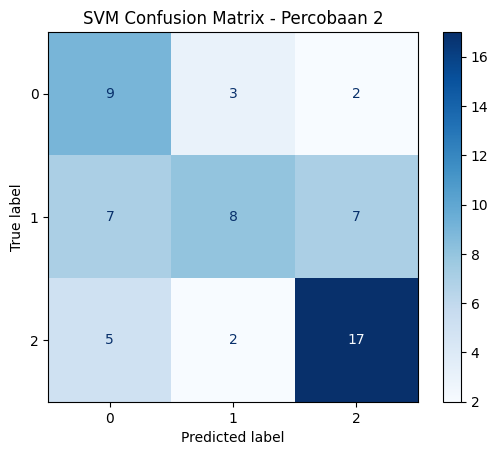

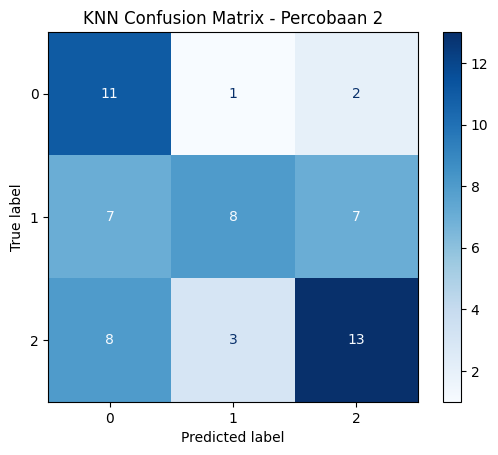

In [60]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 2")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 2")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 2")

In [61]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi_Percobaan2.csv', index=False)
print("✅ File hasil_klasifikasi_Percobaan2.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi_Percobaan2.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.936975,0.500000,0.539052,0.500000,0.487318
1,SVM,0.613445,0.566667,0.587179,0.566667,0.559619
2,KNN,0.617647,0.533333,0.579526,0.533333,0.526969
